In [6]:
import qutip as qt
from qutip import sigmax, sigmay, sigmaz, tensor, basis, sesolve, mesolve, expect, qeye, Qobj
import numpy as np
import matplotlib.pyplot as plt

X = sigmax
Y = sigmay
Z = sigmaz

# 5-1
## (a)

In [14]:
freq_rabi = 0.1 # Mz

# addressing freqs MHz
c1 = np.array([0.413 / 2, -0.413 / 2])
c2 = np.array([0.089 / 2, -0.089 / 2])

deltas = (c1[:, None] + c2) # generate four frequencies
print(deltas)

# shift so 11 phase shift = 0
deltas_a = deltas + deltas[0, 0]
print(deltas_a)

# generate density matrix for hamiltonian
c_density = np.diag(deltas_a.flatten())
print(c_density)

def H_NV(drive, detuning_matrix):
   H_drift = tensor(1/2*Z(), Qobj(detuning_matrix, dims=[[2,2],[2,2]]))
   H_drive = drive*tensor(1/2*X(), qeye(2), qeye(2))
   return 2*np.pi * (H_drift + H_drive)

[[ 0.251  0.162]
 [-0.162 -0.251]]
[[0.502 0.413]
 [0.089 0.   ]]
[[0.502 0.    0.    0.   ]
 [0.    0.413 0.    0.   ]
 [0.    0.    0.089 0.   ]
 [0.    0.    0.    0.   ]]


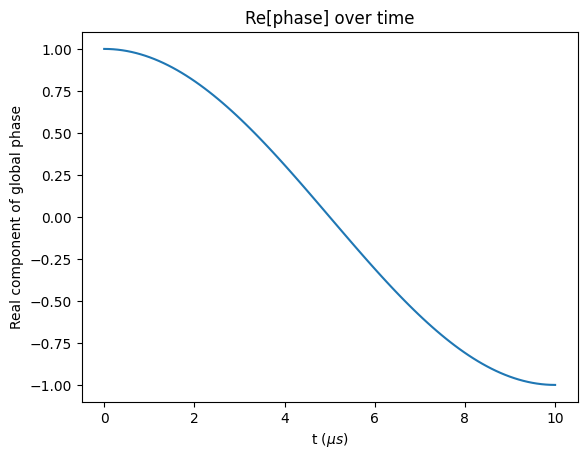

In [18]:
# Run simulation for one full transition
T = np.linspace(0, 10, 100)

H_total_q1 = H_NV(freq_rabi, c_density)

up = basis(2, 1)
down = basis(2, 0)
ket_init = tensor(down, up, up)
solution = sesolve(H_total_q1, ket_init, T)

# Calculate global phase over time and plot
phase = np.real([ket_init.dag() * state for state in solution.states])

plt.title('Re[phase] over time')
plt.plot(T, phase)
plt.xlabel(r"t ($\mu s$)")
plt.ylabel(r"Real component of global phase")
plt.show()

## (b)

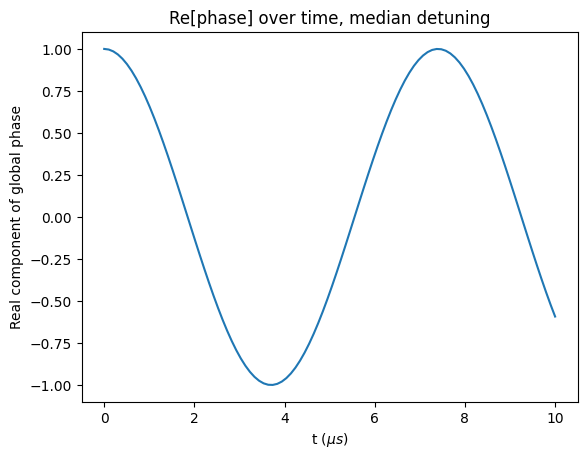

In [21]:
# Use originally calculated detuning matrix, which was already cenetered at median
# Note: already have maximal control from construction of H_NV function
centered_detuning = np.diag(deltas.flatten())

H_centered = H_NV(freq_rabi, centered_detuning)

solution = sesolve(H_centered, ket_init, T)

# Calculate global phase over time and plot
phase = np.real([ket_init.dag() * state for state in solution.states])

plt.title('Re[phase] over time, median detuning')
plt.plot(T, phase)
plt.xlabel(r"t ($\mu s$)")
plt.ylabel(r"Real component of global phase")
plt.show()

## (d)
NOTE: After trying (and failing) to find documentation for `optimize_pulse_unitary` in modern QuTiP, I discovered it was moved to the qutip-qtrl library, which I install here:

In [23]:
%pip install qutip-qtrl

Note: you may need to restart the kernel to use updated packages.


In [26]:
import qutip_qtrl.pulseoptim as qtq
from qutip_qtrl.pulseoptim import optimize_pulse_unitary

In [31]:
# separate into different parts for later use

H_detuning = 2 * np.pi * tensor(0.5*Z(), Qobj(centered_detuning, dims=[[2,2],[2,2]]))

H_c_y = 2 * np.pi * 0.5 * tensor(Y(), qeye(2), qeye(2))
H_c_x = 2 * np.pi * 0.5 * tensor(X(), qeye(2), qeye(2))
# Need control in both directions for phase control
H_control = [H_c_x, H_c_y]

# Initial state: identity for unitary evolution
U_0 = tensor(qeye(2), qeye(2), qeye(2))

targ_array = np.eye(8)

# Create the ideal CPhase gate that targets 011 and 111
targ_array[3, 3] = -1
targ_array[7, 7] = -1

U_targ = Qobj(targ_array, dims=[[2,2,2],[2,2,2]])

result = optimize_pulse_unitary(H_detuning, H_control, U_0, U_targ, evo_time=10, num_tslots=100)

def infidelity(ideal, actual):
    d = actual.shape[0]
    fidelity = 1/d * np.abs((ideal.dag() * actual).tr())
    return 1 - fidelity

U_actual_resonant = qt.propagator(H_total_q1, 10.0)
error_resonant = infidelity(U_targ, U_actual_resonant)
error_optimized = infidelity(U_targ, result.evo_full_final)


In [33]:
print(f"Error for resonant case: {error_resonant:.4g}")
print(f"Error for optimized non-resonant case: {error_optimized:.4g}")

Error for resonant case: 0.927
Error for optimized non-resonant case: 0.02276


As we can see, the optimized pulse sequence has an improvement over the naive resonant pulse by an order of magnitude.

## (e)

In [45]:
# Generate basis states
k000 = tensor(down, down, down)
k001 = tensor(down, down, up)
k010 = tensor(down, up, down)
k011 = tensor(down, up, up)

equal = (k000 + k001 + k010 + k011).unit()

test_states = [
    k000, k001, k010, k011, equal
]

fidelities_optimized = []
fidelities_naive = []

# Calculate unitaries
optimized_unitary = optimize_pulse_unitary(H_detuning, H_control, U_0, U_targ, num_tslots=100, evo_time=10).evo_full_final
naive_unitary = qt.propagator(H_total_q1, 10.0)

for state in test_states:
    # Final states
    ideal = U_targ * state
    optimized = optimized_unitary * state
    naive = naive_unitary * state

    fidelities_optimized.append(qt.fidelity(ideal, optimized))
    fidelities_naive.append(qt.fidelity(ideal, naive))

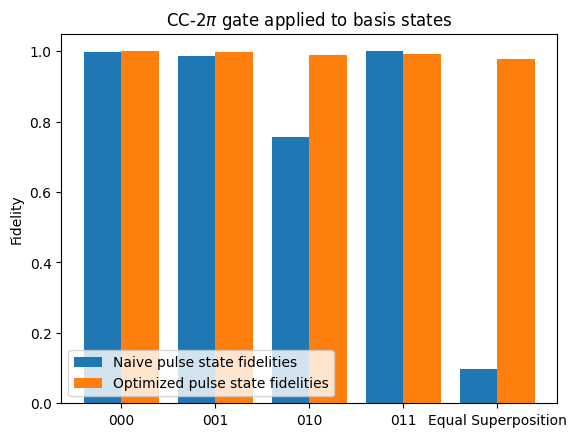

In [52]:
# Plotting code

state_names = [
    '000',
    '001',
    '010',
    '011',
    'Equal Superposition'
]

bar_width = 0.4

x = np.arange(len(state_names))

plt.bar(x - bar_width/2, fidelities_naive, bar_width, label="Naive pulse state fidelities")

plt.bar(x + bar_width/2, fidelities_optimized, bar_width, label="Optimized pulse state fidelities");

plt.ylabel("Fidelity")
plt.legend(loc='lower left')

plt.xticks(x, state_names)
plt.title(r"CC-$2\pi$ gate applied to basis states")
plt.show()

## (f)
From our results, it is fairly obvious that the optimized pulse sequence significantly outperforms the naive pulse sequence overall, sucessfully counteracting phase drift for most of the basis states. While the naive pulse affects most of the exclusive basis states equally well, with respectable fidelities, the 010 state is noted to decohere much more than the other states. While the 011 state has a decoherance delta of 0.0 MHz, the 010 state has that of 0.089--not far enough that it significantly prevents partial driving of this basis, which leads to a partial X gate being performed instead of the identity matrix. The other basis states are not as affected by this because the detuning between drive frequency and resonant frequency is too large.

It should be noted that the equal superposition is especially devistated by the naive pulse, most likely because its different components all get adjusted in the X axis to different degrees, essentially introducing more relative phase differences that ultimately destroy the fidelity of the final state.

While the optimized pulse gate performs better than the naive pulse for most states, there is one exception. The 011 state maintains slightly better fidelity with the naive pulse, because it is specifically tuned to that state's resonant frequency. The tradeoff that the optimizer algorithm makes to prevent massive decoherances for the 010 and superposition states is that it can't maintain quite as high fidelities for the 011 state, but weighs the overall benefit to coherenace over the miniscule gain the naive pulse sequence has for the 011 case.

## (5-2)

## (a)
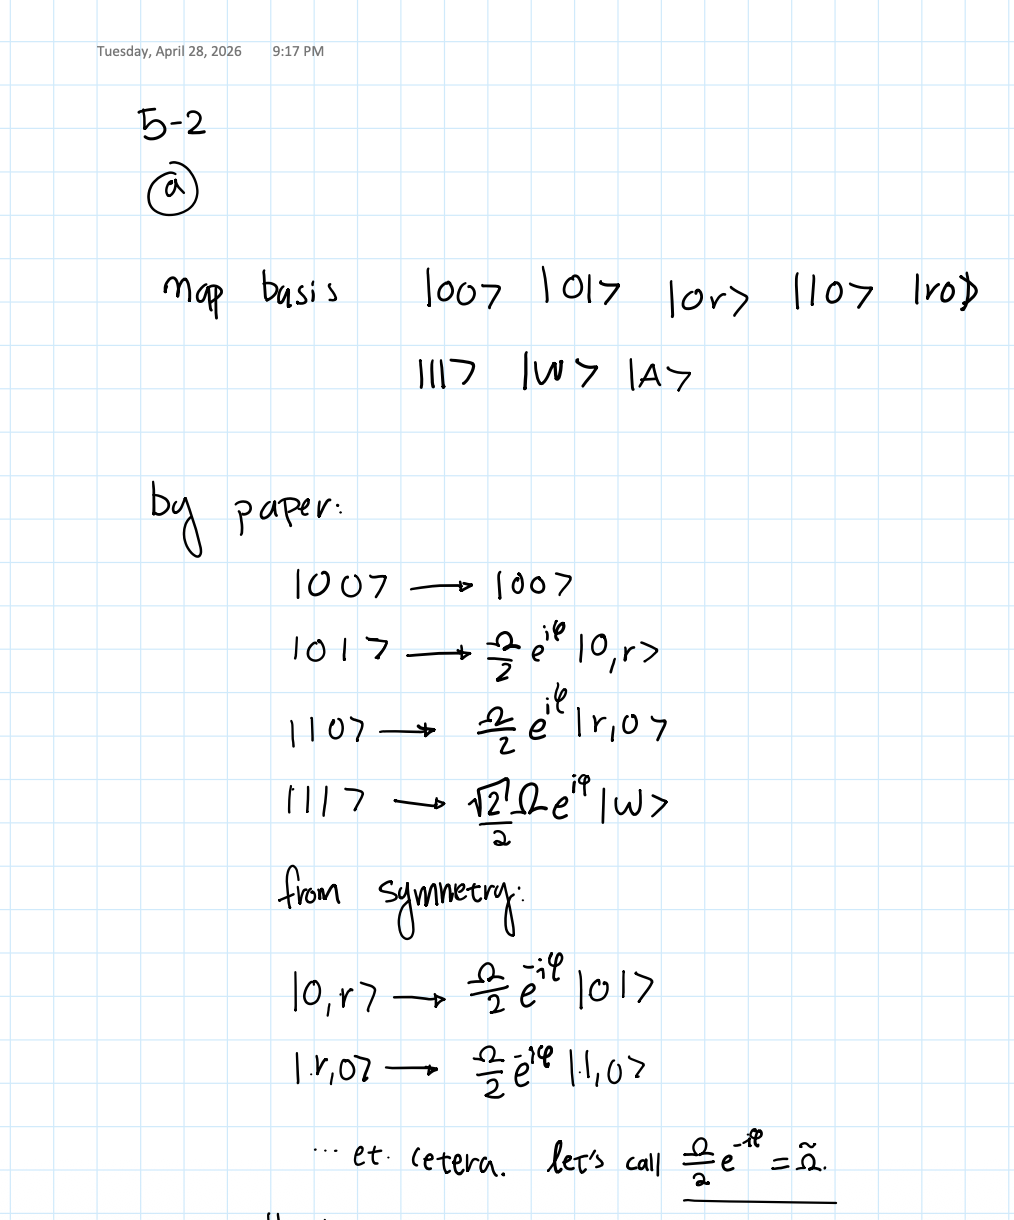
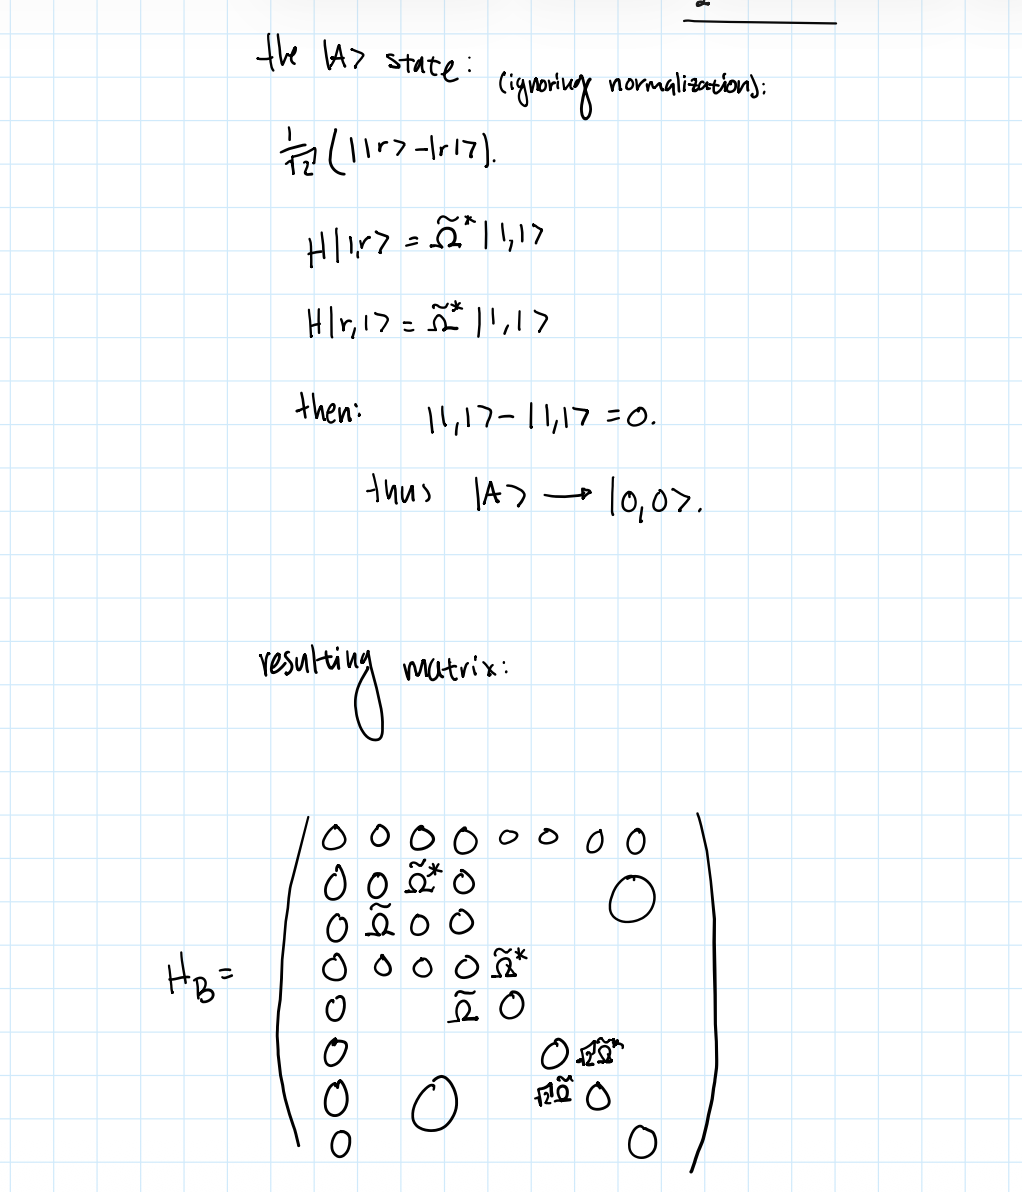
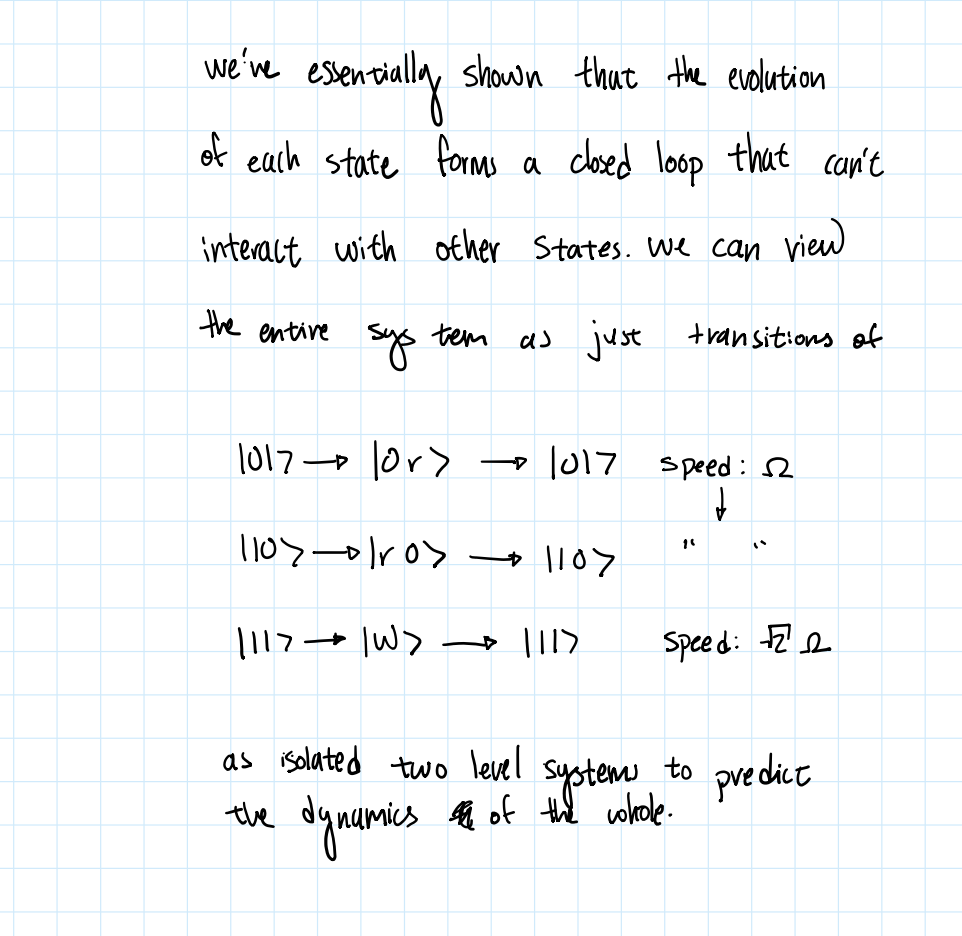

## (b)

In [54]:

# Define basis states as suggested in (a)
b00 = basis(8, 0)
b01 = basis(8, 1)
b0r = basis(8, 2)
b10 = basis(8, 3)
br0 = basis(8, 4)
b11 = basis(8, 5)
bW  = basis(8, 6)
bA  = basis(8, 7)

def H_b(phi):
    """
    Generates Hamiltonian H_B / Omega for a given laser phase phi.
    """
    return 0.5 * (
        np.exp(-1j * phi) * b0r * b01.dag() + np.exp(1j * phi) * b01 * b0r.dag() +
        np.exp(-1j * phi) * br0 * b10.dag() + np.exp(1j * phi) * b10 * br0.dag() +
        np.sqrt(2) * (np.exp(-1j * phi) * bW * b11.dag() + np.exp(1j * phi) * b11 * bW.dag())
    )

# we can create the Hx and Hy operators by evaluating the function at specific phases
Hx = H_b(0)
Hy = H_b(np.pi / 2)

# Generating the unitary sequence...
def U_gate(epsilon):
    t1 = (1 + epsilon) * np.pi / (2 * np.sqrt(2))
    t2 = (1 + epsilon) * np.pi
    t3 = (1 + epsilon) * np.pi / np.sqrt(2)
    
    Ux_t1 = (-1j * Hx * t1).expm()
    Uy_t2 = (-1j * Hy * t2).expm()
    Ux_t3 = (-1j * Hx * t3).expm()
    
    return Ux_t1 * Uy_t2 * Ux_t3 * Uy_t2 * Ux_t1

# Run the gate
psi_i = 0.5 * (b00 + b01 + b10 + b11)

psi_f_ideal = U_gate(0) * psi_i

# Demonstrating we can recover the correct bell state out of this using
# single qubit operations:

# note that we need to construct Z, I, and H gates from the ground up
# because I chose to work in essentially 8 dimensions...
# maybe there's a better way to do this?
# oh well I think it works

Z_Z = b00 * b00.dag() - b01 * b01.dag() - b10 * b10.dag() + b11 * b11.dag() # 

I_H = (1/np.sqrt(2)) * (
    b00 * b00.dag() + b01 * b00.dag() + b00 * b01.dag() - b01 * b01.dag() +
    b10 * b10.dag() + b11 * b10.dag() + b10 * b11.dag() - b11 * b11.dag()
)

psi_bell_actual = I_H * Z_Z * psi_f_ideal
bell_target = (b00 + b11).unit()

print(f"Fidelity to Bell State |Phi+>: {qt.fidelity(bell_target, psi_bell_actual)}")

Fidelity to Bell State |Phi+>: 0.9999999999999998


## (c) (bonus)

Pardon my clunky implementation of this--it probably would have been cleaner to have just used `sesolve` and calculated the frequencies, but I originally thought that doing it geometrically would be faster. I might have been wrong, but I think this works regardless:

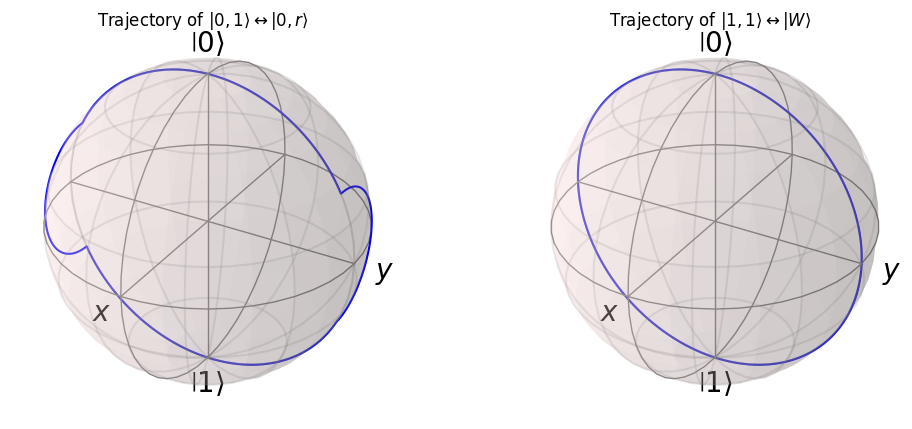

In [ ]:
H_list = [Hx, Hy, Hx, Hx, Hy, Hx]
a_list = [
    np.pi / (2 * np.sqrt(2)),
    np.pi,
    np.pi / (2 * np.sqrt(2)),
    np.pi / (2 * np.sqrt(2)),
    np.pi,
    np.pi / (2 * np.sqrt(2))
]

# assemble X Y and Z operators for our 8-basis kets
# kinda bad form I suppose? I mentioned above but not
# really sure how else to do this

X_01 = b0r * b01.dag() + b01 * b0r.dag()
Y_01 = -1j * b0r * b01.dag() + 1j * b01 * b0r.dag()
Z_01 = b0r * b0r.dag() - b01 * b01.dag()

X_11 = bW * b11.dag() + b11 * bW.dag()
Y_11 = -1j * bW * b11.dag() + 1j * b11 * bW.dag()
Z_11 = bW * bW.dag() - b11 * b11.dag()

# initial kets
psi_01 = b01
psi_11 = b11

# need to use x y and z components sadly
x01, y01, z01 = [], [], []
x11, y11, z11 = [], [], []

# evaluate at a bunch of time steps to get an approximation of the
# complete bloch evaluation
steps = 50

for H, a in zip(H_list, a_list):
    thetas = np.linspace(0, a, steps)
    for theta in thetas:
        U = (-1j * H * theta).expm() # step it forwards
        
        state_01 = U * psi_01
        x01.append(expect(X_01, state_01))
        y01.append(expect(Y_01, state_01))
        z01.append(expect(Z_01, state_01))
        
        state_11 = U * psi_11
        x11.append(expect(X_11, state_11))
        y11.append(expect(Y_11, state_11))
        z11.append(expect(Z_11, state_11))
    
    # save our final state to pick up from next iteration
    U_full = (-1j * H * a).expm()
    psi_01 = U_full * psi_01
    psi_11 = U_full * psi_11

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
bloch_01 = qt.Bloch(fig=fig, axes=ax1)
bloch_01.add_points([x01, y01, z01], meth='l')
bloch_01.render()
ax1.set_title(r"Trajectory of $|0,1\rangle \leftrightarrow |0,r\rangle$")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
bloch_11 = qt.Bloch(fig=fig, axes=ax2)
bloch_11.add_points([x11, y11, z11], meth='l')
bloch_11.render()
ax2.set_title(r"Trajectory of $|1,1\rangle \leftrightarrow |W\rangle$")

plt.show();

## (d)

Calculated power n: 2.0055


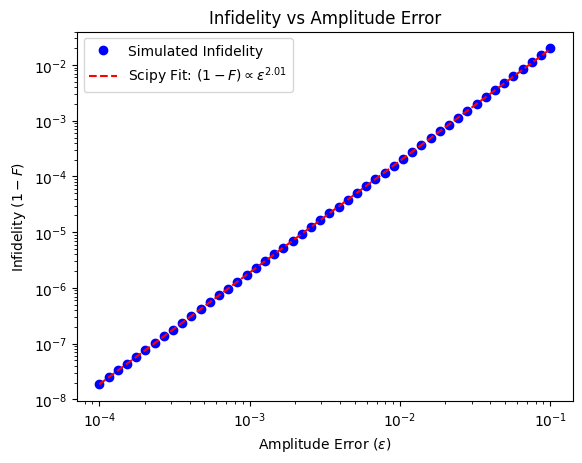

In [74]:
from scipy.stats import linregress

epsilons = np.logspace(-4, -1, 50) # really small epsilon as suggested
infidelities = []

for eps in epsilons:
    U_eps = U_gate(eps)
    psi_f_eps = U_eps * psi_i
    
    overlap = psi_f_ideal.overlap(psi_f_eps)
    F = np.abs(overlap)**2
    
    infidelities.append(1 - F)

# run a linear fit on the data to see what kind of power we get
log_eps = np.log10(epsilons)
log_infid = np.log10(infidelities)

n, intercept, r_value, p_value, std_err = linregress(log_eps, log_infid)

print(f"Calculated power n: {n:.4f}")

plt.loglog(epsilons, infidelities, 'bo', label='Simulated Infidelity')

fit_line = (10**intercept) * (epsilons**n)
plt.loglog(epsilons, fit_line, 'r--', label=fr'Scipy Fit: $(1-F) \propto \epsilon^{{{n:.2f}}}$')

plt.title(r'Infidelity vs Amplitude Error')
plt.xlabel(r'Amplitude Error ($\epsilon$)')
plt.ylabel(r'Infidelity ($1 - F$)')
plt.legend()
plt.show()

We see that at small epsilon, the infidelity scales roughly proportional to $\epsilon^2$. Not super great.

## (e)

Calculated power n': 4.0401


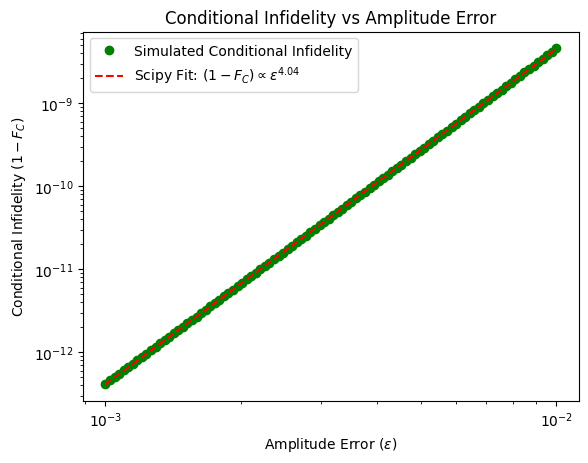

In [73]:
# Define our filtering operator that tosses nonn-computational states
Pc = b00 * b00.dag() + b01 * b01.dag() + b10 * b10.dag() + b11 * b11.dag()

conditional_infidelities = []

# NOTE: I had to use larger epsilons because of floating point error,
# and also truncated them since it looks like the error scaling was better
# to the point 10^-1 was outside the e << 1 range
epsilons = np.logspace(-3, -2, 100)

for eps in epsilons:
    U_eps = U_gate(eps)
    psi_f_eps = U_eps * psi_i
    
    psi_conditional = (Pc * psi_f_eps).unit() # can just use unit() to do the same thing as the denominator
                                              #in the equation
    
    overlap = psi_f_ideal.overlap(psi_conditional)
    F_c = np.abs(overlap)**2
    
    conditional_infidelities.append(1 - F_c)

log_eps = np.log10(epsilons)
log_infid_c = np.log10(conditional_infidelities)

# same as above, let's get that linregress
n_prime, intercept, _, _, _ = linregress(log_eps, log_infid_c)

print(f"Calculated power n': {n_prime:.4f}")

plt.loglog(epsilons, conditional_infidelities, 'go', label='Simulated Conditional Infidelity')

fit_line_c = (10**intercept) * (epsilons**n_prime) # adjust to fit graph
plt.loglog(epsilons, fit_line_c, 'r--', label=fr'Scipy Fit: $(1-F_C) \propto \epsilon^{{{n_prime:.2f}}}$')

plt.title(r'Conditional Infidelity vs Amplitude Error')
plt.xlabel(r'Amplitude Error ($\epsilon$)')
plt.ylabel(r'Conditional Infidelity ($1 - F_C$)')
plt.legend()
plt.show()

By throwing out the parts of the wavefunction stuck in the rydberg state, we have demonstrated that in the small error range, we get an improvement of error scaling to the power of four! That's an order of two better than without this correction!

## (f)

We can generalize the $\pi/2$ gates demonstrated in fig. 2 not by changing the shape of the path, but by changing the enclosed area as suggested in the caption under figure 1. As the amount of accumulated phase is related to the net angle travelled around the bloch sphere, to get a phase angle of arbitrary angle $\theta$ we could simply change the azimuthal angle traversed by the gate to be the $\theta$, or as the paper describes, by adding a phase jump $\xi = \pi-\theta$ to the laser pulse while the phase is at the "north pole" of the bloch sphere.

Calculated power n for fully robust protocol: 4.0402


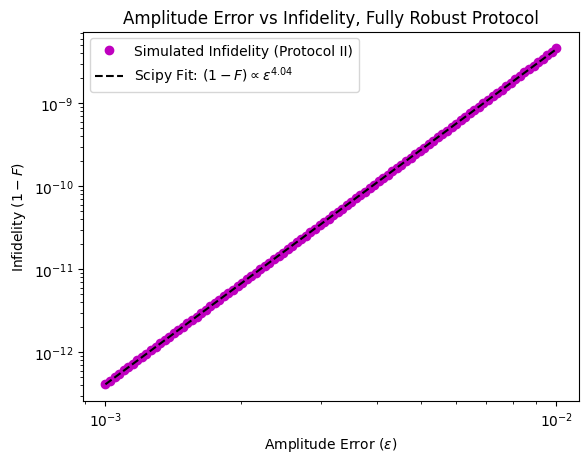

In [72]:
def fully_robust_gate(epsilon):
    """
    Construct the fully robust gate 
    """
    a1 = (1 + epsilon) * np.pi / (2 * np.sqrt(2))
    a2 = (1 + epsilon) * np.pi
    
    xi = np.pi - (np.pi / 2) # verbose for explicitness

    # following is from eqn. 5 from paper
    H_up_1 = H_b(0)
    H_up_2 = H_b(np.pi / 2)
    H_up_3 = H_b(0)
    
    H_dn_1 = H_b(0 + xi)
    H_dn_2 = H_b(np.pi / 2 + xi)
    H_dn_3 = H_b(0 + xi)
    
    U_up = (-1j * H_up_3 * a1).expm() * (-1j * H_up_2 * a2).expm() * (-1j * H_up_1 * a1).expm()
    
    U_dn = (-1j * H_dn_3 * a1).expm() * (-1j * H_dn_2 * a2).expm() * (-1j * H_dn_1 * a1).expm()
    
    C_pi_2 = U_dn * U_up
    
    return C_pi_2 * C_pi_2

psi_i = 0.5 * (b00 + b01 + b10 + b11) # let's put together a robust test state in a superposition
U_ideal = fully_robust_gate(0)
psi_f_ideal = U_ideal * psi_i

epsilons = np.logspace(-3, -2, 100)
infidelities = []

for eps in epsilons:
    U_eps = fully_robust_gate(eps)
    psi_f_eps = U_eps * psi_i
    
    overlap = psi_f_ideal.overlap(psi_f_eps)
    F = np.abs(overlap)**2
    
    infidelities.append(1 - F)

log_eps = np.log10(epsilons)
log_infid = np.log10(infidelities)

n, intercept, _, _, _ = linregress(log_eps, log_infid)

print(f"Calculated power n for fully robust protocol: {n:.4f}")

plt.loglog(epsilons, infidelities, 'mo', label='Simulated Infidelity (Protocol II)')

fit_line = (10**intercept) * (epsilons**n)
plt.loglog(epsilons, fit_line, 'k--', label=fr'Scipy Fit: $(1-F) \propto \epsilon^{{{n:.2f}}}$')

plt.title(r'Amplitude Error vs Infidelity, Fully Robust Protocol')
plt.xlabel(r'Amplitude Error ($\epsilon$)')
plt.ylabel(r'Infidelity ($1 - F$)')
plt.legend()
plt.show()

We also see that the infidelity scales proportionally to $\epsilon^4$ for the second protocol! Even though we didn't throw out the rydberg leakage states, we essentially used a property similar to the spin echo technique we saw back in NMR to cancel out the leakage from the two parts of the operation, yielding the same error scaling as the first method for removing state leakage.